# ERP/ERF analysis

This example will show how to use mean-centred PLS for analyzing ERP/ERF data.

In [1]:
import mne
import mne_plsc

We will use the MNE example data, which in [...]. The data is from a single subject. However, to demonstrate the syntax for analyzing multiple participants, we will split the data into 3 sets of trials and pretend that these are separate participants.

In [51]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file)
events = mne.find_events(raw, stim_channel="STI 014")
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4
}
raw.pick_types(meg='grad')
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2, tmax=0.5,
    preload=True
)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Not setting metadata
288 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 288 events and 106 original time points ...
0 bad epochs dropped


In [43]:
labels = mne_plsc.utils.get_epoch_labels(epochs)
res = mne_plsc.fit_mc(epochs, between=labels)

Permuting: 100%|███████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 63.37it/s]


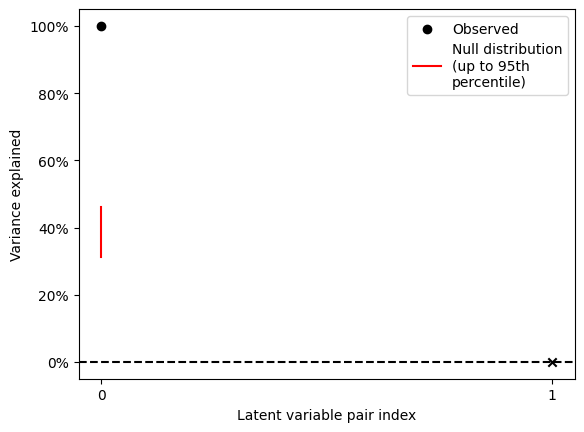

In [44]:
res.permute(50)
res.plot_scree()

C:\Users\isaac\Projects\mne-plsc\src\mne_plsc\__init__.py:572: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 640x480 with 3 Axes>,
 array([<Axes: ylabel='Brain score'>,
        <Axes: xlabel='Time (s)', ylabel='Salience'>], dtype=object))

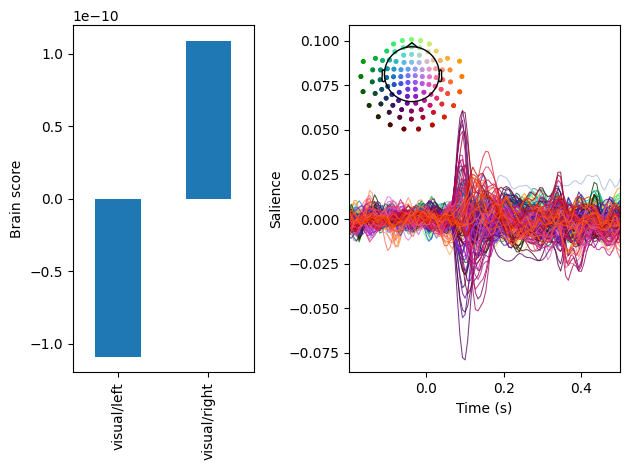

In [45]:
res.plot_lv(0)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Brain score'>)

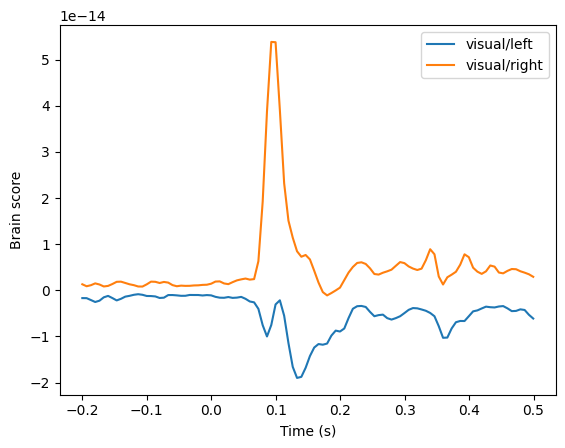

In [46]:
res.plot_marginal_brain_scores(0, 'time')

In [47]:
res.add_adjacency()

Defaulting to all channels adjacent for ERP analysis


Computing clusters for lv_idx 0...
7 clusters
Computing clusters for lv_idx 1...
19 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

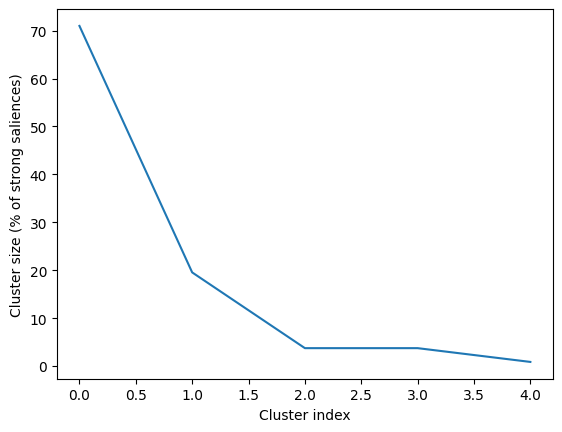

In [48]:
import mne_plsc
import numpy as np
res.cluster(threshold=0.02)
res.plot_cluster_sizes(0, n_clust=5)

IndexError: index 112 is out of bounds for axis 0 with size 101

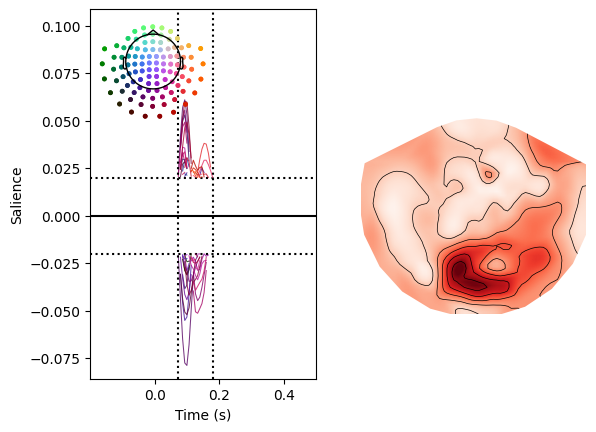

In [50]:
res.plot_clusters(0, 0)